In [3]:
# ===============================
# SECTION 1: Imports
# ===============================

import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np

In [4]:
# ===============================
# SECTION 2: Device
# ===============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ===============================
# SECTION 3: Original Dataset Paths
# ===============================

base_dir = "/kaggle/input/oral-diseases"
batch_size = 32

# ===============================
# SECTION 4: Dataset Structure Scan
# ===============================

image_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".gif")

def scan_recursive(folder_path):
    subfolder_list = []
    image_count = 0
    
    for root, dirs, files in os.walk(folder_path):
        for d in dirs:
            subfolder_list.append(os.path.join(root, d))
        for f in files:
            if f.lower().endswith(image_ext):
                image_count += 1

    return subfolder_list, image_count


total_images = 0
total_subfolders = 0

print("\n📊 FULL DATASET STRUCTURE\n")

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    subfolders, image_count = scan_recursive(class_path)

    print(f"\n📁 CLASS: {class_name}")
    print(f"   📂 Subfolders: {len(subfolders)}")
    print(f"   🖼️ Images: {image_count}")

    total_images += image_count
    total_subfolders += len(subfolders)

print("\n" + "="*60)
print(f"TOTAL IMAGES: {total_images}")
print(f"TOTAL SUBFOLDERS: {total_subfolders}")
print("="*60)

Using device: cuda

📊 FULL DATASET STRUCTURE


📁 CLASS: Data caries
   📂 Subfolders: 5
   🖼️ Images: 2601

📁 CLASS: Mouth Ulcer
   📂 Subfolders: 5
   🖼️ Images: 2806

📁 CLASS: Tooth Discoloration
   📂 Subfolders: 5
   🖼️ Images: 2017

📁 CLASS: hypodontia
   📂 Subfolders: 1
   🖼️ Images: 1251

📁 CLASS: Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
   📂 Subfolders: 8
   🖼️ Images: 1542

📁 CLASS: Gingivitis
   📂 Subfolders: 1
   🖼️ Images: 2349

📁 CLASS: Calculus
   📂 Subfolders: 1
   🖼️ Images: 1296

TOTAL IMAGES: 13862
TOTAL SUBFOLDERS: 26


In [5]:
# ===============================
# SECTION 5: Dataset Cleaning
# ===============================

clean_dir = "/kaggle/working/clean-dataset"
os.makedirs(clean_dir, exist_ok=True)

exclude_folders = [
    "Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset"
]

print("🚀 Cleaning dataset...\n")

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    if class_name in exclude_folders:
        print(f"❌ Skipping: {class_name}")
        continue

    output_class_dir = os.path.join(clean_dir, class_name)
    os.makedirs(output_class_dir, exist_ok=True)

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(image_ext):
                src = os.path.join(root, file)
                dst = os.path.join(output_class_dir, file)

                if os.path.exists(dst):
                    name, ext = os.path.splitext(file)
                    dst = os.path.join(output_class_dir, f"{name}_dup{ext}")

                shutil.copy(src, dst)

    count = len(os.listdir(output_class_dir))
    print(f"✔ {class_name}: {count} images")

print("\n✅ Clean dataset ready:", clean_dir)

🚀 Cleaning dataset...

✔ Data caries: 2601 images
✔ Mouth Ulcer: 2806 images
✔ Tooth Discoloration: 2017 images
✔ hypodontia: 1251 images
❌ Skipping: Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
✔ Gingivitis: 2349 images
✔ Calculus: 1296 images

✅ Clean dataset ready: /kaggle/working/clean-dataset


In [6]:
# ===============================
# SECTION 6: Verify Clean Dataset
# ===============================

print("\n📊 VERIFYING CLEAN DATASET\n")

total_images = 0

for class_name in os.listdir(clean_dir):
    class_path = os.path.join(clean_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path) if f.lower().endswith(image_ext)]
    subfolders = [d for d in os.listdir(class_path) if os.path.isdir(os.path.join(class_path, d))]

    print(f"{class_name}: {len(images)} images | subfolders: {len(subfolders)}")
    total_images += len(images)

print("\nTOTAL IMAGES:", total_images)


📊 VERIFYING CLEAN DATASET

Tooth Discoloration: 2017 images | subfolders: 0
Gingivitis: 2349 images | subfolders: 0
hypodontia: 1251 images | subfolders: 0
Data caries: 2601 images | subfolders: 0
Calculus: 1296 images | subfolders: 0
Mouth Ulcer: 2806 images | subfolders: 0

TOTAL IMAGES: 12320


In [7]:
# ===============================
# SECTION 7: Class Balancing via Targeted Augmentation
# ===============================

from torchvision.transforms import functional as TF
import random

balanced_dir = "/kaggle/working/balanced-dataset"
os.makedirs(balanced_dir, exist_ok=True)

# Copy all original clean data first
for class_name in os.listdir(clean_dir):
    src_class = os.path.join(clean_dir, class_name)
    dst_class = os.path.join(balanced_dir, class_name)
    os.makedirs(dst_class, exist_ok=True)

    for img in os.listdir(src_class):
        shutil.copy(os.path.join(src_class, img), os.path.join(dst_class, img))

# Augmentation transforms (strong but realistic)
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0))
])

from PIL import Image

def augment_to_target(class_name, target_count):
    class_path = os.path.join(balanced_dir, class_name)
    images = os.listdir(class_path)
    current_count = len(images)

    idx = 0
    while current_count < target_count:
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert("RGB")
        aug_img = augment_transform(img)

        new_name = f"aug_{idx}_{img_name}"
        aug_img.save(os.path.join(class_path, new_name))

        idx += 1
        current_count += 1

# Apply augmentation only to required classes
augment_to_target("hypodontia", 2500)
augment_to_target("Calculus", 2500)

print("✅ Class balancing complete")


✅ Class balancing complete


In [8]:
# ===============================
# SECTION 8: Verify Balanced Dataset
# ===============================

print("\n📊 BALANCED DATASET SUMMARY\n")
total_images = 0
for class_name in os.listdir(balanced_dir):
    count = len(os.listdir(os.path.join(balanced_dir, class_name)))
    print(f"{class_name}: {count}")
    total_images += count

print("TOTAL IMAGES:", total_images)



📊 BALANCED DATASET SUMMARY

Tooth Discoloration: 2017
Gingivitis: 2349
hypodontia: 2500
Data caries: 2601
Calculus: 2500
Mouth Ulcer: 2806
TOTAL IMAGES: 14773


In [9]:
# ===============================
# SECTION 9: Train / Val / Test Split (70/15/15)
# ===============================

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(balanced_dir, transform=transform_train)

total_len = len(full_dataset)
train_len = int(0.70 * total_len)
val_len   = int(0.15 * total_len)
test_len  = total_len - train_len - val_len

train_set, val_set, test_set = random_split(full_dataset, [train_len, val_len, test_len])

# Override transforms for val/test
val_set.dataset.transform = transform_eval
test_set.dataset.transform = transform_eval

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("\nSplits:")
print(f"Train: {len(train_set)}")
print(f"Val:   {len(val_set)}")
print(f"Test:  {len(test_set)}")


Splits:
Train: 10341
Val:   2215
Test:  2217


In [10]:
# ===============================
# SECTION 10: Modified EfficientNet Backbone
# ===============================

class ModifiedEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

num_classes = len(full_dataset.classes)
model = ModifiedEfficientNet(num_classes).to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 194MB/s]


In [12]:
# ===============================
# SECTION 11: Training Setup
# ===============================

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)


In [13]:
# ===============================
# SECTION 12: Training Loop
# ===============================

def train_model(model, epochs=25):
    best_acc = 0

    train_losses = [] 
    val_losses = [] 
    val_accuracies = [] 
    train_accuracies = [] 

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_preds, train_gts = [], [] 

        for imgs, labels in tqdm(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1) 
            train_preds.extend(predicted.cpu().numpy()) 
            train_gts.extend(labels.cpu().numpy()) 

        train_losses.append(train_loss) 
        train_acc = accuracy_score(train_gts, train_preds) 
        train_accuracies.append(train_acc) 
        
        model.eval()
        preds, gts = [], []
        val_loss = 0 
        
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels) 
                val_loss += loss.item() 
                _, predicted = torch.max(outputs, 1)
                preds.extend(predicted.cpu().numpy())
                gts.extend(labels.cpu().numpy())

        val_acc = accuracy_score(gts, preds)
        val_losses.append(val_loss) 
        val_accuracies.append(val_acc) 
        scheduler.step(val_acc)

        print(f"Epoch [{epoch+1}] Loss: {train_loss:.3f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")

    print("\n✅ Training complete")
    return train_losses, val_losses, val_accuracies, train_accuracies 

train_losses, val_losses, val_accuracies, train_accuracies = train_model(model) 

100%|██████████| 324/324 [01:03<00:00,  5.10it/s]


Epoch [1] Loss: 130.895 | Val Acc: 0.9391


100%|██████████| 324/324 [01:02<00:00,  5.21it/s]


Epoch [2] Loss: 60.173 | Val Acc: 0.9467


100%|██████████| 324/324 [01:02<00:00,  5.22it/s]


...

Epoch [23] Loss: 21.686 | Val Acc: 0.9454


100%|██████████| 324/324 [01:02<00:00,  5.14it/s]


Epoch [24] Loss: 21.516 | Val Acc: 0.9454


100%|██████████| 324/324 [01:02<00:00,  5.17it/s]


Epoch [25] Loss: 22.102 | Val Acc: 0.9445

✅ Training complete


In [15]:
# ===============================
# SECTION 13: Final Evaluation
# ===============================

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nCLASSIFICATION REPORT:\n")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))



CLASSIFICATION REPORT:

                     precision    recall  f1-score   support

           Calculus       0.86      0.82      0.84       373
        Data caries       0.98      1.00      0.99       370
         Gingivitis       0.82      0.88      0.85       348
        Mouth Ulcer       1.00      1.00      1.00       440
Tooth Discoloration       1.00      0.97      0.99       296
         hypodontia       0.99      0.99      0.99       390

           accuracy                           0.94      2217
          macro avg       0.94      0.94      0.94      2217
       weighted avg       0.95      0.94      0.94      2217



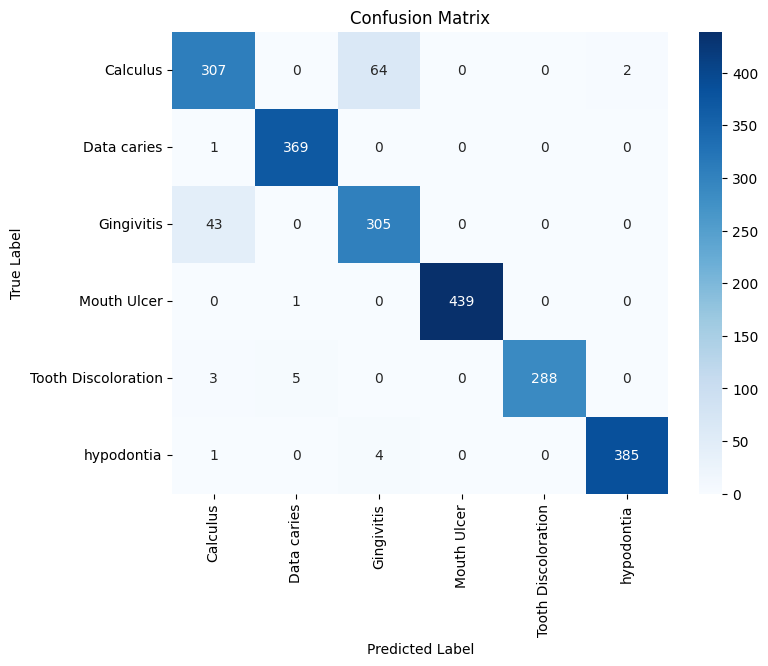

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=full_dataset.classes,
    yticklabels=full_dataset.classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

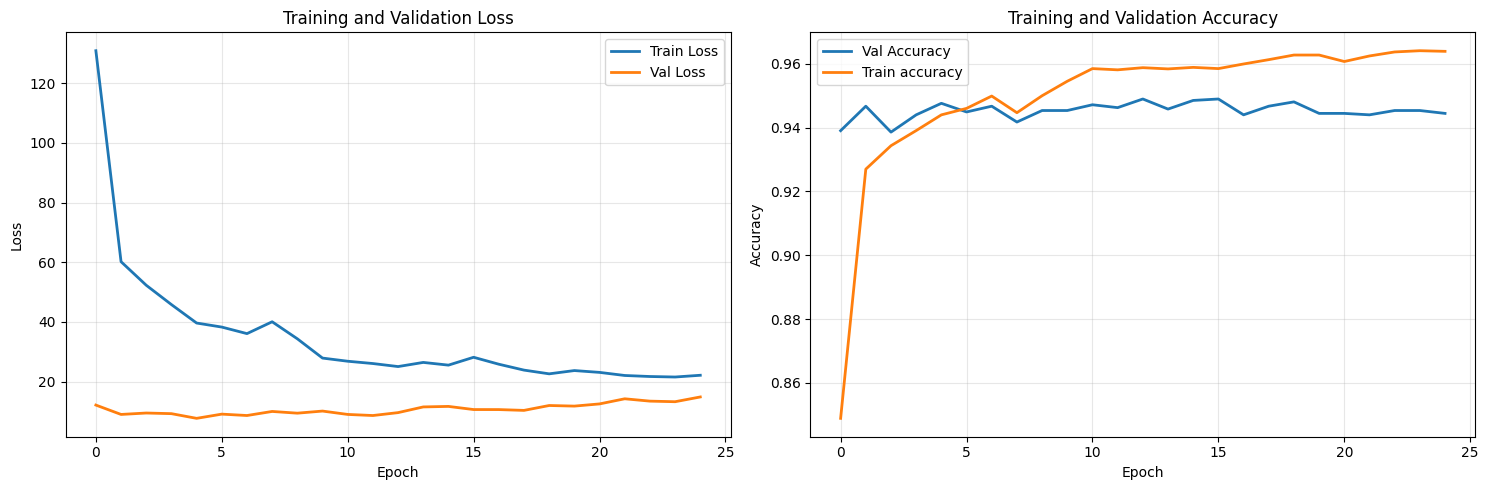

In [19]:
def plot_training_history(train_losses, val_losses, val_accuracies, train_accuracies):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Val Loss', linewidth=2)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Val Accuracy', linewidth=2)
    plt.plot(train_accuracies, label='Train accuracy', linewidth=2)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(train_losses, val_losses, val_accuracies, train_accuracies)